# Decision Tree Regression

Разбор того, как работает дерево решений для регрессии:

- как дерево делает разбиения
- что хранится в листьях (среднее значение target)
- влияние `max_depth` (глубины) на качество и переобучение
- метрики: **MSE, RMSE, R², MAE**
- разные `criterion`: `squared_error`, `absolute_error`, `friedman_mse`, `poisson`
- сравнение criterion и max_depth

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

## 1. Сгенерируем датасет

Сгенерируем синусоиду с шумом — так удобно увидеть «ступеньки» предсказаний дерева.

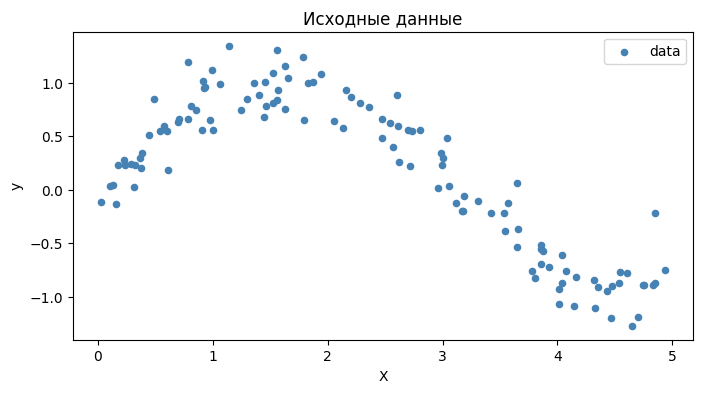

In [40]:
X = np.sort(np.random.uniform(0, 5, 120)).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

plt.figure(figsize=(8, 4))
plt.scatter(X, y, s=20, color='steelblue', label='data')
plt.title('Исходные данные')
plt.xlabel('X'); plt.ylabel('y'); plt.legend(); plt.show()

## 2. Как дерево делает разбиения

Дерево регрессии в каждом узле ищет такой порог по признаку, чтобы **разделить выборку на две части и минимизировать ошибку**.

В **листьях** хранится одно число — обычно **среднее значение y** объектов, попавших в лист. Поэтому предсказание выглядит как «лесенка».

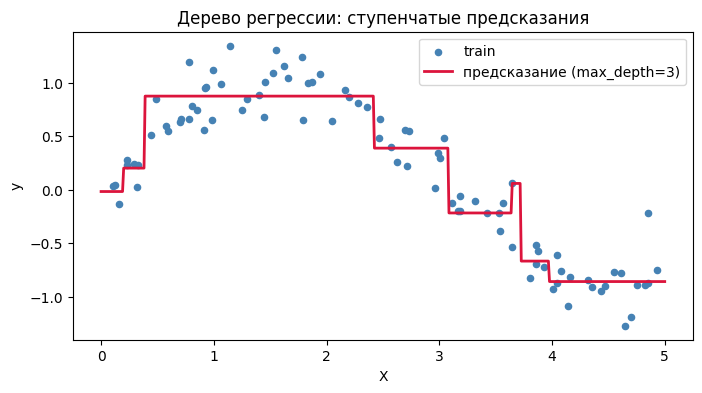

In [41]:
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

X_grid = np.linspace(0, 5, 500).reshape(-1, 1)
y_pred_grid = tree.predict(X_grid)

plt.figure(figsize=(8, 4))
plt.scatter(X_train, y_train, s=20, color='steelblue', label='train')
plt.plot(X_grid, y_pred_grid, color='crimson', lw=2, label='предсказание (max_depth=3)')
plt.title('Дерево регрессии: ступенчатые предсказания')
plt.xlabel('X'); plt.ylabel('y'); plt.legend(); plt.show()

Каждая горизонтальная «ступенька» — это лист дерева, и её высота = среднее `y` в этом листе.

## 3. Влияние `max_depth` (глубины)

- маленькая глубина → недообучение (слишком грубо);
- большая глубина / `None` → переобучение (дерево запоминает шум).

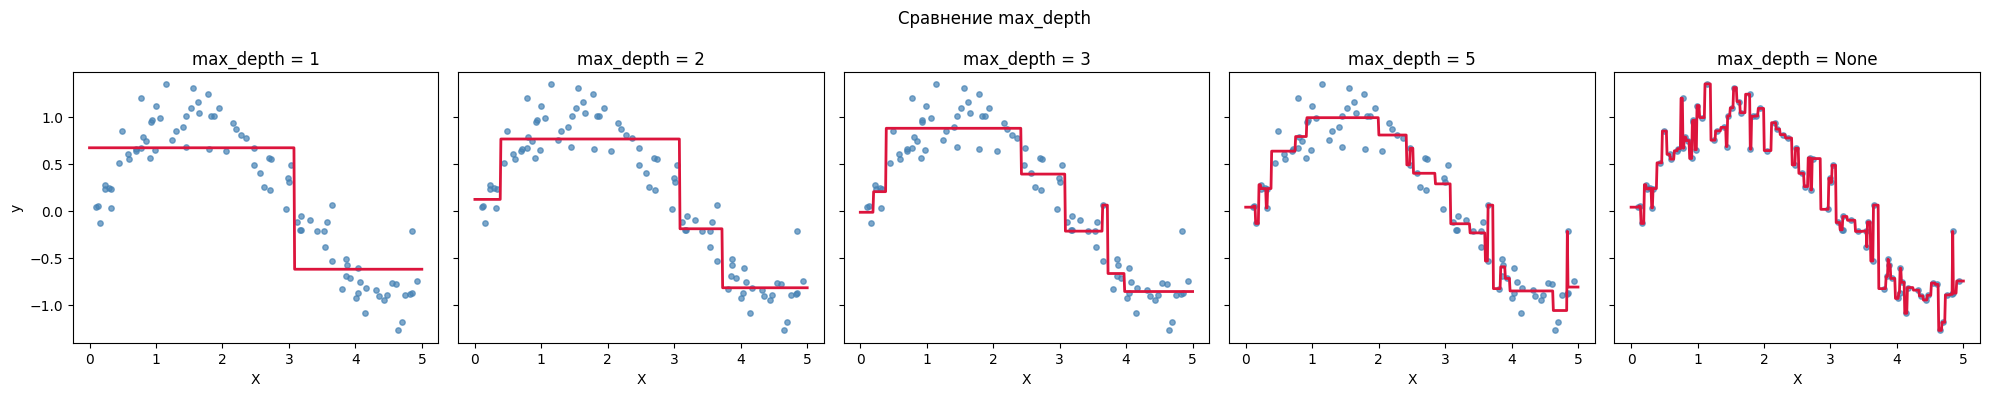

In [42]:
depths = [1, 2, 3, 5, None]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, d in zip(axes, depths):
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    ax.scatter(X_train, y_train, s=15, color='steelblue', alpha=0.7, label='train')
    ax.plot(X_grid, model.predict(X_grid), color='crimson', lw=2)
    ax.set_title(f'max_depth = {d}')
    ax.set_xlabel('X')
axes[0].set_ylabel('y')
plt.suptitle('Сравнение max_depth')
plt.tight_layout(); plt.show()

In [43]:
rows = []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train, y_train)
    rows.append({
        'max_depth': str(d),
        'R2_train': r2_score(y_train, m.predict(X_train)),
        'R2_test':  r2_score(y_test,  m.predict(X_test)),
        'MSE_test': mean_squared_error(y_test, m.predict(X_test)),
    })
pd.DataFrame(rows)

,max_depth,R2_train,R2_test,MSE_test
0,1,0.757637,0.749423,0.118694
1,2,0.880550,0.844659,0.073582
2,3,0.929466,0.848380,0.071820
3,5,0.963783,0.879664,0.057001
4,None,1.000000,0.816598,0.086874


Видно классическую картину: при росте глубины `R2_train` стремится к 1, а `R2_test` сначала растёт, потом может падать — это и есть переобучение.

## 4. Визуализация дерева через `plot_tree`

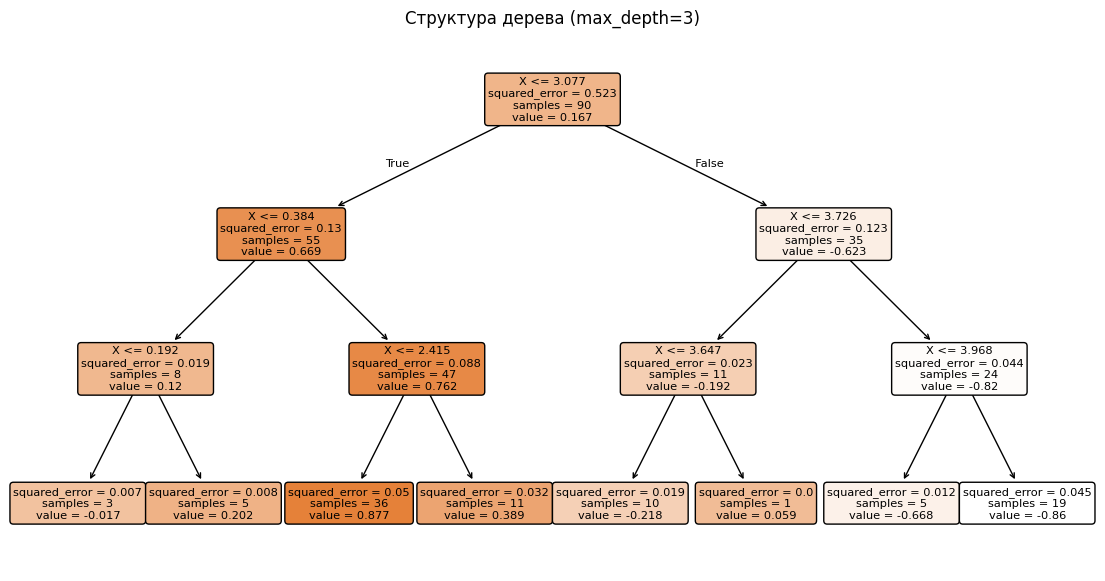

In [44]:
tree3 = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(tree3, feature_names=['X'], filled=True, rounded=True, precision=3)
plt.title('Структура дерева (max_depth=3)')
plt.show()

В каждом листе видно `value = ...` — это и есть среднее значение target по объектам, попавшим в лист.

## 5. Метрики: MSE, RMSE, R², MAE

MSE     0.0718
RMSE    0.2680
MAE     0.2115
R2      0.8484
dtype: float64


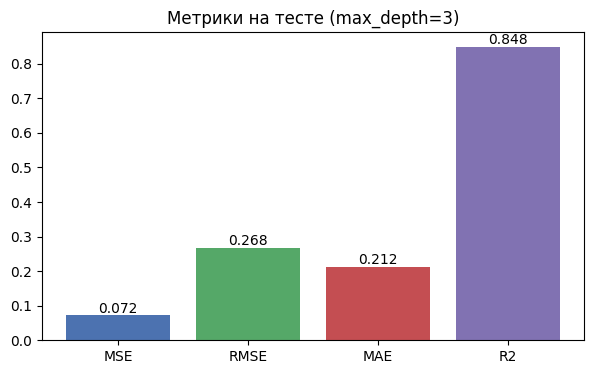

In [45]:
best = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, y_train)
y_pred = best.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

metrics = pd.Series({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
print(metrics.round(4))

plt.figure(figsize=(7, 4))
plt.bar(metrics.index, metrics.values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
for i, v in enumerate(metrics.values):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')
plt.title('Метрики на тесте (max_depth=3)')
plt.show()

## 6. Critеrion в `DecisionTreeRegressor`

В sklearn у дерева есть 4 функции потерь для разбиений: `squared_error`, `absolute_error`, `friedman_mse`, `poisson`.

`poisson` требует, чтобы `y >= 0`, поэтому для него возьмём сдвинутый таргет.

In [46]:
criteria = ['squared_error', 'absolute_error', 'friedman_mse', 'poisson']

shift = abs(y_train.min()) + 1
y_train_pos = y_train + shift
y_test_pos  = y_test  + shift

results = []
for c in criteria:
    yt, yv = (y_train_pos, y_test_pos) if c == 'poisson' else (y_train, y_test)
    m = DecisionTreeRegressor(criterion=c, max_depth=3, random_state=42).fit(X_train, yt)
    yp = m.predict(X_test)
    results.append({
        'criterion': c,
        'MSE':  mean_squared_error(yv, yp),
        'RMSE': np.sqrt(mean_squared_error(yv, yp)),
        'MAE':  mean_absolute_error(yv, yp),
        'R2':   r2_score(yv, yp),
    })

df_crit = pd.DataFrame(results).set_index('criterion')
df_crit.round(4)

,MSE,RMSE,MAE,R2
criterion,,,,
squared_error,0.0718,0.2680,0.2115,0.8484
absolute_error,0.0677,0.2603,0.2047,0.8570
friedman_mse,0.0718,0.2680,0.2115,0.8484
poisson,0.0718,0.2680,0.2115,0.8484


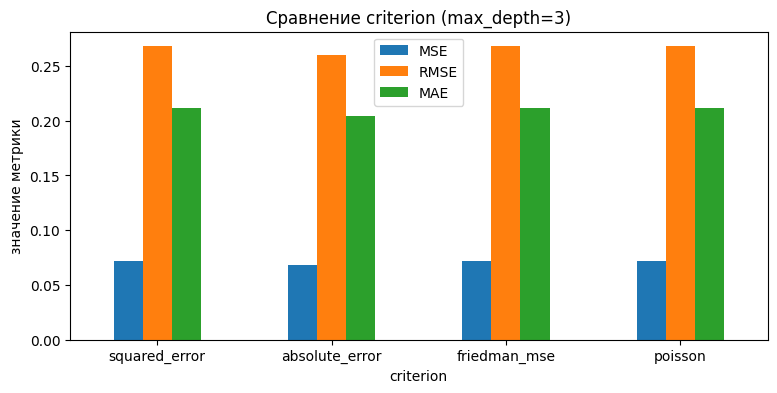

In [47]:
df_crit[['MSE', 'RMSE', 'MAE']].plot(kind='bar', figsize=(9, 4))
plt.title('Сравнение criterion (max_depth=3)')
plt.ylabel('значение метрики'); plt.xticks(rotation=0); plt.show()

## 7. Сравнение criterion и max_depth

In [48]:
depths_grid = [1, 2, 3, 5, 10, None]
grid = []
for c in criteria:
    yt, yv = (y_train_pos, y_test_pos) if c == 'poisson' else (y_train, y_test)
    for d in depths_grid:
        m = DecisionTreeRegressor(criterion=c, max_depth=d, random_state=42).fit(X_train, yt)
        grid.append({
            'criterion': c,
            'max_depth': str(d),
            'R2_test': r2_score(yv, m.predict(X_test)),
        })

df_grid = pd.DataFrame(grid).pivot(index='max_depth', columns='criterion', values='R2_test')
df_grid = df_grid.reindex([str(d) for d in depths_grid])
df_grid.round(3)

criterion,absolute_error,friedman_mse,poisson,squared_error
max_depth,,,,
1,0.775,0.749,0.749,0.749
2,0.851,0.845,0.845,0.845
3,0.857,0.848,0.848,0.848
5,0.859,0.880,0.880,0.880
10,0.818,0.820,0.820,0.820
None,0.817,0.817,0.817,0.817


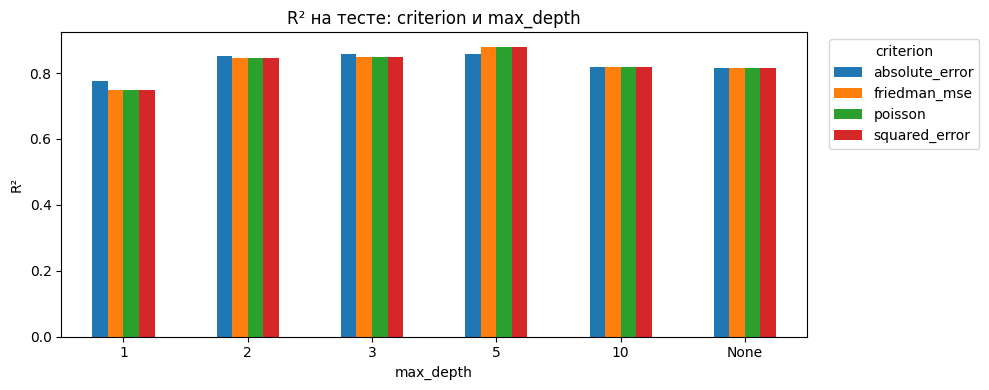

In [49]:
df_grid.plot(kind='bar', figsize=(10, 4))
plt.title('R² на тесте: criterion и max_depth')
plt.ylabel('R²'); plt.xticks(rotation=0)
plt.legend(title='criterion', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

## 8. Feature importance

Чтобы важность признаков была интереснее, возьмём датасет с несколькими фичами.

R2 test: 0.635


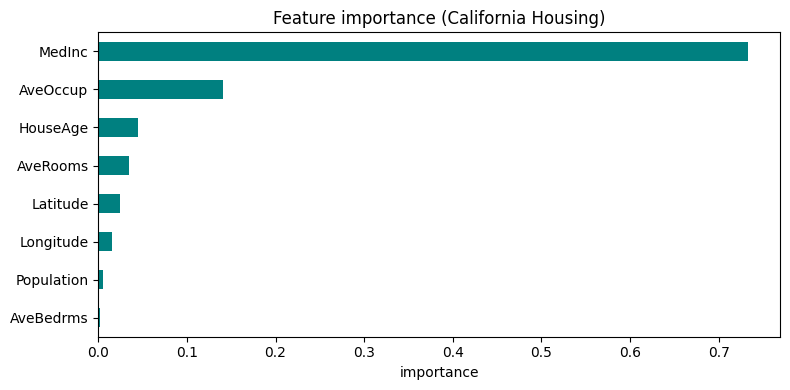

In [50]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
Xc, yc = data.data, data.target

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.25, random_state=42)

model = DecisionTreeRegressor(max_depth=6, random_state=42).fit(Xc_tr, yc_tr)
print('R2 test:', round(r2_score(yc_te, model.predict(Xc_te)), 3))

imp = pd.Series(model.feature_importances_, index=Xc.columns).sort_values()

plt.figure(figsize=(8, 4))
imp.plot(kind='barh', color='teal')
plt.title('Feature importance (California Housing)')
plt.xlabel('importance'); plt.tight_layout(); plt.show()

#**Общий итог:**

- Дерево регрессии режет пространство признаков порогами и в листьях хранит **одно число** (среднее или медиану).
- `max_depth` (глубина) — главный регулятор сложности: маленькая → недообучение, большая → переобучение.
- Для оценки качества удобно смотреть сразу несколько метрик: **MSE, RMSE, MAE, R²**.
- В sklearn доступно 4 criterion: `squared_error`, `absolute_error`, `friedman_mse`, `poisson` — на «обычных» данных результаты часто близкие, но `absolute_error` устойчивее к выбросам, а `poisson` подходит для счётных таргетов.